# ML Ensemble Models for IoT IDS

## Models Implemented:
1. **Random Forest** - Bagging ensemble
2. **XGBoost** - Gradient boosting ensemble
3. **CatBoost** - Gradient boosting ensemble with categorical features support

## Evaluation Metrics:
- Accuracy, Precision, Recall, F1-Score, Mcc
- ROC-AUC, PR-AUC
- Confusion Matrix
- Classification Report

In [1]:
import os
import time
import joblib
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from xgboost import XGBClassifier
from catboost import CatBoostClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (accuracy_score, precision_score, recall_score, f1_score,
                            roc_auc_score, average_precision_score, confusion_matrix,
                            classification_report, matthews_corrcoef, roc_curve, precision_recall_curve)
from sklearn.model_selection import train_test_split, cross_val_score, GridSearchCV, RandomizedSearchCV
from imblearn.over_sampling import SMOTENC


In [2]:
np.random.seed(42)
RANDOM_STATE = 42

## 1. Data Loading and Preprocessing

Load the preprocessed data from the data preprocessing notebook.


In [3]:
# Load the preprocessed data
def load_preprocessed_data():
    try:
        X_train = pd.read_csv('data/preprocessedTrain.csv')
        X_test = pd.read_csv('data/preprocessedTest.csv')

        # Separate features and target
        benign = ['MQTT_Publish', 'Thing_Speak', 'Wipro_bulb']
        y_train = X_train.pop('Attack_type')
        y_train = pd.DataFrame([0 if x in benign else 1 for x in y_train]).squeeze()

        y_test = X_test.pop('Attack_type')
        y_test = pd.DataFrame([0 if x in benign else 1 for x in y_test]).squeeze()

        print("Preprocessed data loaded successfully!")
        print(f"\nFeatures shape: {X_train.shape}")
        print(f"Target shape: {y_train.shape}")

        return X_train, X_test, y_train, y_test

    except FileNotFoundError as e:
        print(f"Error loading preprocessed data: {e}")
        print("Please make sure you have run the CSI4999_dataPreprocessing.ipynb notebook first.")
        print("Expected files: data/preprocessedTrain.csv and data/preprocessedTest.csv")
        return None, None, None, None

X_train, X_test, y_train, y_test = load_preprocessed_data()

Preprocessed data loaded successfully!

Features shape: (98493, 83)
Target shape: (98493,)


### Split train-val

In [4]:
X_train, X_val, y_train, y_val = train_test_split(
    X_train, y_train, test_size=0.2, random_state=42, stratify=y_train
)

X_train["Attack_type"] = y_train
print("Train class counts:\n", X_train["Attack_type"].value_counts())
X_train.pop('Attack_type')
print("="*20)

Train class counts:
 Attack_type
1    70790
0     8004
Name: count, dtype: int64


## 2. Model Definition and Configuration

Define all the ensemble models with base hyperparameter configurations.

In [9]:
# Define model configurations
def get_model_configs():
    models = {}

    models['RandomForest'] = {
        'model': RandomForestClassifier(
            class_weight='balanced',
            random_state=RANDOM_STATE,
            n_jobs=-1
        ),
        'param_grid': {
            'n_estimators': [50, 100, 200],
            'max_depth': [5, 10, 15, None],
            'min_samples_split': [2, 5, 10],
            'min_samples_leaf': [1, 2, 4],
        }
    }

    models['XGBoost'] = {
        'model': XGBClassifier(
            random_state= RANDOM_STATE,
            n_jobs= -1,
            objective= 'binary:logistic',
            scale_pos_weight= (len(y_train) - y_train.sum()) / y_train.sum()),
        'param_grid': {
            'n_estimators': [50, 100, 200],
            'max_depth': [3, 5, 6],
            'learning_rate': [0.01, 0.1, 0.3],
            'min_child_weight':[1,5,10],
            'colsample_bytree': [.6,.8,1],
        }
    }

    models['CatBoost'] = {
        'model': CatBoostClassifier(
            random_state=RANDOM_STATE,
            thread_count=-1,
            verbose=False,
            auto_class_weights='Balanced',
            loss_function='Logloss'
        ),
        'param_grid': {
            'iterations': [50, 100, 200],
            'depth': [3, 5, 6],
            'learning_rate': [0.01, 0.1, 0.3],
            'l2_leaf_reg': [1, 3, 5],
            'bootstrap_type': ['Bayesian', 'Bernoulli'],
        }
    }

    return models

model_configs = get_model_configs()

## 3. Model Training and Hyperparameter Tuning

#### Baseline models


In [10]:
rf_base = RandomForestClassifier(random_state=RANDOM_STATE,
                            verbose=1,
                            class_weight='balanced',).fit(X_train,y_train)

print(classification_report(y_train, rf_base.predict(X_train)))
print("Validation\n",classification_report(y_val,rf_base.predict(X_val),digits=4))

[Parallel(n_jobs=1)]: Done  49 tasks      | elapsed:    2.4s
[Parallel(n_jobs=1)]: Done 100 out of 100 | elapsed:    5.2s finished
[Parallel(n_jobs=1)]: Done  49 tasks      | elapsed:    0.0s


              precision    recall  f1-score   support

           0       1.00      1.00      1.00      8004
           1       1.00      1.00      1.00     70790

    accuracy                           1.00     78794
   macro avg       1.00      1.00      1.00     78794
weighted avg       1.00      1.00      1.00     78794

Validation
               precision    recall  f1-score   support

           0     0.9920    0.9935    0.9928      2001
           1     0.9993    0.9991    0.9992     17698

    accuracy                         0.9985     19699
   macro avg     0.9956    0.9963    0.9960     19699
weighted avg     0.9985    0.9985    0.9985     19699



[Parallel(n_jobs=1)]: Done 100 out of 100 | elapsed:    0.2s finished
[Parallel(n_jobs=1)]: Done  49 tasks      | elapsed:    0.0s
[Parallel(n_jobs=1)]: Done 100 out of 100 | elapsed:    0.0s finished


In [11]:
catboost_base = CatBoostClassifier(
    random_state=RANDOM_STATE,
    thread_count=-1,
    verbose=1,
    auto_class_weights='Balanced',
    loss_function='Logloss'
).fit(X_train, y_train)

print(classification_report(y_train, catboost_base.predict(X_train)))
print("Validation\n",classification_report(y_val, catboost_base.predict(X_val),digits=4))

Learning rate set to 0.066487
0:	learn: 0.4938624	total: 150ms	remaining: 2m 30s
1:	learn: 0.3873337	total: 176ms	remaining: 1m 27s
2:	learn: 0.2809923	total: 201ms	remaining: 1m 6s
3:	learn: 0.2255505	total: 228ms	remaining: 56.7s
4:	learn: 0.1737955	total: 258ms	remaining: 51.4s
5:	learn: 0.1337313	total: 283ms	remaining: 46.9s
6:	learn: 0.1038154	total: 307ms	remaining: 43.6s
7:	learn: 0.0834805	total: 338ms	remaining: 41.9s
8:	learn: 0.0707873	total: 359ms	remaining: 39.5s
9:	learn: 0.0609361	total: 397ms	remaining: 39.3s
10:	learn: 0.0509838	total: 418ms	remaining: 37.6s
11:	learn: 0.0454012	total: 439ms	remaining: 36.1s
12:	learn: 0.0410900	total: 461ms	remaining: 35s
13:	learn: 0.0374899	total: 477ms	remaining: 33.6s
14:	learn: 0.0328335	total: 492ms	remaining: 32.3s
15:	learn: 0.0302667	total: 507ms	remaining: 31.2s
16:	learn: 0.0287471	total: 521ms	remaining: 30.1s
17:	learn: 0.0268334	total: 535ms	remaining: 29.2s
18:	learn: 0.0247753	total: 548ms	remaining: 28.3s
19:	learn: 

In [12]:
xgb_base = XGBClassifier(booster='gbtree',
                    objective='binary:logistic',
                    seed=RANDOM_STATE,
                    verbosity=2,
                    scale_pos_weight= (len(y_train) - y_train.sum()) / y_train.sum(),
                    ).fit(X_train,y_train)
print(classification_report(y_train, xgb_base.predict(X_train)))
print("Validation\n",classification_report(y_val, xgb_base.predict(X_val),digits=4))

[13:47:04] INFO: D:\bld\xgboost-split_1762060125444\work\src\data\iterative_dmatrix.cc:56: Finished constructing the `IterativeDMatrix`: (78794, 83, 6467942).
              precision    recall  f1-score   support

           0       0.99      1.00      1.00      8004
           1       1.00      1.00      1.00     70790

    accuracy                           1.00     78794
   macro avg       1.00      1.00      1.00     78794
weighted avg       1.00      1.00      1.00     78794

Validation
               precision    recall  f1-score   support

           0     0.9842    0.9975    0.9908      2001
           1     0.9997    0.9982    0.9990     17698

    accuracy                         0.9981     19699
   macro avg     0.9920    0.9978    0.9949     19699
weighted avg     0.9981    0.9981    0.9981     19699



#### Hyperparameter Tuning

In [13]:
def tune_model(model, param_grid, X_train, y_train, model_name, use_random_search=True):
    print(f"\n{'='*50}")
    print(f"Training {model_name}")
    print(f"{'='*50}")

    # Hyperparameter tuning
    if use_random_search:
        search = RandomizedSearchCV(
            model, param_grid, n_iter=20, cv=5, scoring='f1',
            random_state=RANDOM_STATE, n_jobs=-1, verbose=2
        )
    else:
        search = GridSearchCV(
            model, param_grid, cv=5, scoring='f1',
            n_jobs=-1, verbose=2
        )

    search.fit(X_train, y_train)
    best_model = search.best_estimator_
    print(f"Best parameters: {search.best_params_}")
    print(f"Best CV score: {search.best_score_:.4f}")

    return best_model

In [14]:
tune_model(model_configs['XGBoost']['model'],model_configs['XGBoost']['param_grid'],X_train,y_train,'xgb')


Training xgb
Fitting 5 folds for each of 20 candidates, totalling 100 fits
Best parameters: {'n_estimators': 200, 'min_child_weight': 1, 'max_depth': 6, 'learning_rate': 0.3, 'colsample_bytree': 1}
Best CV score: 0.9990


,objective,'binary:logistic'
,base_score,None
,booster,None
,callbacks,None
,colsample_bylevel,None
,colsample_bynode,None
,colsample_bytree,1
,device,None
,early_stopping_rounds,None
,enable_categorical,False
,eval_metric,None


In [15]:
tune_model(model_configs['CatBoost']['model'],model_configs['CatBoost']['param_grid'],X_train,y_train,'CatBoost')



Training CatBoost
Fitting 5 folds for each of 20 candidates, totalling 100 fits


c:\Users\willo_jlqcl0r\miniconda3\envs\caps\Lib\site-packages\sklearn\model_selection\_validation.py:516: FitFailedWarning: 
1 fits failed out of a total of 100.
The score on these train-test partitions for these parameters will be set to nan.
If these failures are not expected, you can try to debug them by setting error_score='raise'.

Below are more details about the failures:
--------------------------------------------------------------------------------
1 fits failed with the following error:
Traceback (most recent call last):
  File "c:\Users\willo_jlqcl0r\miniconda3\envs\caps\Lib\site-packages\sklearn\model_selection\_validation.py", line 859, in _fit_and_score
    estimator.fit(X_train, y_train, **fit_params)
  File "c:\Users\willo_jlqcl0r\miniconda3\envs\caps\Lib\site-packages\catboost\core.py", line 5245, in fit
    self._fit(X, y, cat_features, text_features, embedding_features, None, graph, sample_weight, None, None, None, None, baseline, use_best_model,
  File "c:\Users\wi

Best parameters: {'learning_rate': 0.3, 'l2_leaf_reg': 3, 'iterations': 200, 'depth': 5, 'bootstrap_type': 'Bernoulli'}
Best CV score: 0.9990


In [16]:
tune_model(model_configs['RandomForest']['model'],model_configs['RandomForest']['param_grid'],X_train,y_train,'RF')


Training RF
Fitting 5 folds for each of 20 candidates, totalling 100 fits
Best parameters: {'n_estimators': 200, 'min_samples_split': 2, 'min_samples_leaf': 1, 'max_depth': None}
Best CV score: 0.9991


,n_estimators,200
,criterion,'gini'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,'sqrt'
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


In [17]:
bestCatBoost = CatBoostClassifier(
    random_state=RANDOM_STATE,
    thread_count=-1,
    verbose=0,
    auto_class_weights='Balanced',
    loss_function='Logloss',
    learning_rate=0.3,
    l2_leaf_reg=3,
    iterations=200,
    depth=5,
    bootstrap_type='Bernoulli',
).fit(X_train, y_train)

In [9]:
bestXGB = XGBClassifier(booster='gbtree',
                    n_estimators=200,
                    objective='binary:logistic',
                    seed=RANDOM_STATE,
                    verbosity=0,
                    scale_pos_weight= (len(y_train) - y_train.sum()) / y_train.sum(),
                    learning_rate=0.3,
                    ).fit(X_train,y_train)

In [7]:
bestRF = RandomForestClassifier(n_estimators=200,
                            random_state=RANDOM_STATE,
                            verbose=0,
                            max_depth=None,
                            class_weight='balanced',).fit(X_train,y_train)

In [11]:
# print(classification_report(all_labels, all_preds, target_names=["Benign", "Malicious"],digits=6))
print(classification_report(y_test, bestXGB.predict(X_test),  target_names=["Benign", "Malicious"],digits=6))

              precision    recall  f1-score   support

      Benign   0.988876  0.994804  0.991831      2502
   Malicious   0.999412  0.998734  0.999073     22122

    accuracy                       0.998335     24624
   macro avg   0.994144  0.996769  0.995452     24624
weighted avg   0.998341  0.998335  0.998337     24624



In [21]:
trained_models={}
trained_models['xgb']=bestXGB
trained_models['rf']=bestRF
trained_models['catboost']=bestCatBoost

## 4. Calculate Metrics

In [22]:
def calculate_metrics(model, y_true, model_name):
    y_pred = model.predict(X_test)
    y_pred_proba = model.predict_proba(X_test) if hasattr(model, 'predict_proba') else None

    metrics = {
        'model_name': model_name,
        'accuracy': accuracy_score(y_true, y_pred),
        'precision_macro': precision_score(y_true, y_pred, average='macro'),
        'recall_macro': recall_score(y_true, y_pred, average='macro'),
        'f1_macro': f1_score(y_true, y_pred, average='macro'),
        'precision': precision_score(y_true, y_pred,),
        'recall': recall_score(y_true, y_pred,),
        'f1': f1_score(y_true, y_pred),
        'mcc': matthews_corrcoef(y_true,y_pred),
    }

    # ROC-AUC and PR-AUC (for multiclass)
    if y_pred_proba is not None:
        try:
            metrics['roc_auc_ovr'] = roc_auc_score(y_true, y_pred_proba, multi_class='ovr', average='macro')
            metrics['roc_auc_ovo'] = roc_auc_score(y_true, y_pred_proba, multi_class='ovo', average='macro')
            metrics['pr_auc'] = average_precision_score(y_true, y_pred_proba, average='macro')
        except:
            metrics['roc_auc_ovr'] = None
            metrics['roc_auc_ovo'] = None
            metrics['pr_auc'] = None

    return metrics
all_metrics=[]

In [23]:
catboost_metrics = calculate_metrics(bestCatBoost, y_test, 'catboost')
all_metrics.append(catboost_metrics)
catboost_metrics

{'model_name': 'catboost',
 'accuracy': 0.998862897985705,
 'precision_macro': 0.9958413616448026,
 'recall_macro': 0.9979492402823062,
 'f1_macro': 0.9968924184876437,
 'precision': 0.9996381727725011,
 'recall': 0.9990959226109755,
 'f1': 0.9993669741363719,
 'mcc': 0.993788366467577,
 'roc_auc_ovr': None,
 'roc_auc_ovo': None,
 'pr_auc': None}

In [24]:
xgb_metrics = calculate_metrics(bestXGB,y_test,'xgb')
all_metrics.append(xgb_metrics)
xgb_metrics

{'model_name': 'xgb',
 'accuracy': 0.9983349577647823,
 'precision_macro': 0.9941437982878052,
 'recall_macro': 0.996769224165013,
 'f1_macro': 0.995452024219382,
 'precision': 0.9994119509657574,
 'recall': 0.9987342916553656,
 'f1': 0.9990730063985168,
 'mcc': 0.9909095444113668,
 'roc_auc_ovr': None,
 'roc_auc_ovo': None,
 'pr_auc': None}

In [25]:
rf_metrics = calculate_metrics(bestRF,y_test,'rf')
all_metrics.append(rf_metrics)
rf_metrics

{'model_name': 'rf',
 'accuracy': 0.9984161793372319,
 'precision_macro': 0.9968012042687395,
 'recall_macro': 0.9945103315232273,
 'f1_macro': 0.995652359075855,
 'precision': 0.9988253896543935,
 'recall': 0.9994123496971341,
 'f1': 0.9991187834692817,
 'mcc': 0.991308888740685,
 'roc_auc_ovr': None,
 'roc_auc_ovo': None,
 'pr_auc': None}

##### Timing

In [26]:
def timed_inf(model, X_test):
    # Run one warm-up predict to avoid lazy initialization cost
    _ = model.predict(X_test[:1])
    start = time.perf_counter()
    preds = model.predict(X_test)
    end = time.perf_counter()
    return preds, end - start

def per_sample_latency(model, X):
    latencies = []
    for i in range(len(X)):
        start = time.perf_counter()
        _ = model.predict(X[i:i+1])
        latencies.append(time.perf_counter() - start)
    return np.mean(latencies), np.percentile(latencies, 99)

In [ ]:
for name, model in trained_models.items():
    preds, inf_time = timed_inf(model, X_test)
    mean_latency, percentile =  per_sample_latency(model, X_test)
    print({
        "model": name,
        "total inference_time_sec": inf_time,
        "avg latency per sample": mean_latency * 1e3,
        'perc': percentile
    })

{'model': 'xgb', 'inference_time_sec': 0.04398580000270158, 'per_sample_ms': 11.298931250031456, 'perc': 0.02403022499653162}
{'model': 'rf', 'inference_time_sec': 0.27275570000347216, 'per_sample_ms': 9.498244456646635, 'perc': 0.019477043004735607}
{'model': 'catboost', 'inference_time_sec': 0.011225900001591071, 'per_sample_ms': 4.882605713963383, 'perc': 0.010793868999462579}


## 5. Model Performance Comparison

Compare the performance of all trained models.


In [28]:
# Create performance comparison DataFrame
results_df = pd.DataFrame(all_metrics)
results_df = results_df.set_index('model_name')

# Display results
print("\nModel Performance Comparison:")
print("="*80)

# Sort by F1 score
results_sorted = results_df.sort_values('f1', ascending=False)

# Display key metrics
key_metrics = ['accuracy', 'precision', 'recall', 'f1', 'mcc']
print(results_sorted[key_metrics].round(4))

# Display ROC-AUC if available
if 'roc_auc_ovr' in results_df.columns:
    print("\nROC-AUC Scores:")
    roc_metrics = ['roc_auc_ovr', 'roc_auc_ovo', 'pr_auc']
    available_roc_metrics = [col for col in roc_metrics if col in results_df.columns]
    print(results_sorted[available_roc_metrics].round(4))


Model Performance Comparison:
            accuracy  precision  recall      f1     mcc
model_name                                             
catboost      0.9989     0.9996  0.9991  0.9994  0.9938
rf            0.9984     0.9988  0.9994  0.9991  0.9913
xgb           0.9983     0.9994  0.9987  0.9991  0.9909

ROC-AUC Scores:
           roc_auc_ovr roc_auc_ovo pr_auc
model_name                               
catboost          None        None   None
rf                None        None   None
xgb               None        None   None


### This is probably unnecessary becasue metrics are so close to each other


## 6. Detailed Model Analysis

Analyze the best performing models in detail.


Best performing model: rf
F1-Score (Macro): 0.9991
Accuracy: 0.9984


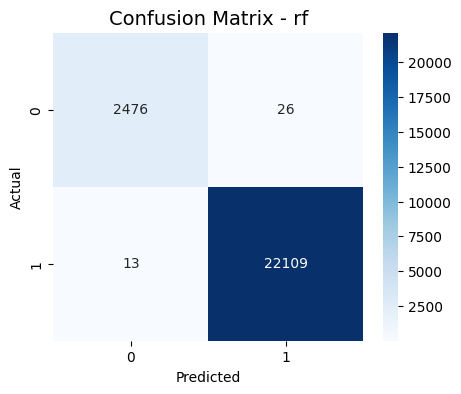

In [29]:
# Get the best model
best_model_name = results_sorted.index[0]
best_model = trained_models[best_model_name]

print(f"Best performing model: {best_model_name}")
print(f"F1-Score (Macro): {results_sorted.loc[best_model_name, 'f1']:.4f}")
print(f"Accuracy: {results_sorted.loc[best_model_name, 'accuracy']:.4f}")

# Make predictions with best model
y_pred_best = best_model.predict(X_test)
y_pred_proba_best = best_model.predict_proba(X_test) if hasattr(best_model, 'predict_proba') else None

# Confusion Matrix
plt.figure(figsize=(5,4))

cm = confusion_matrix(y_test, y_pred_best)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=range(len(np.unique(y_test))),
            yticklabels=range(len(np.unique(y_test))))
plt.title(f'Confusion Matrix - {best_model_name}',fontsize=14)
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.savefig("confusionmatrices/binaryRF.png", dpi=600, bbox_inches='tight')
plt.show()

## 7. Model Saving and Inference Functions

Save the trained models and create inference functions.


In [ ]:
# Create models directory if it doesn't exist
os.makedirs('models', exist_ok=True)

def save_models(trained_models, results_df):
    # Save all trained models
    for model_name, model in trained_models.items():
        model_path = f'models/{model_name.lower()}_binary_model.pkl'
        joblib.dump(model, model_path)
        print(f"Saved {model_name} to {model_path}")

    # Save results
    results_df.to_csv('classification_reports/ml_binary_performance_results.csv')
    print("Saved model performance results to classification_reports/ml_binary_performance_results.csv")

    # Save best model separately
    best_model_name = results_df.index[0]
    best_model = trained_models[best_model_name]
    joblib.dump(best_model, 'models/best_binary_model.pkl')
    print(f"Saved best model ({best_model_name}) to models/best_binary_model.pkl")

save_models(trained_models, results_sorted)

Saved xgb to models/xgb_binary_model.pkl
Saved rf to models/rf_binary_model.pkl
Saved model performance results to classification_reports/ml_binary_performance_results.csv
Saved best model (rf) to models/best_binary_model.pkl
